1.	Загрузите данные, проверьте число наблюдений и столбцов, наличие пропусков. Убедитесь, что типы данных были прочитаны правильно. При необходимости – приведите переменные к нужным типам.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv('C:/Users/majkl/WorkSpace/Project_st_3/london.csv', parse_dates=['timestamp'])
df.head()

,timestamp,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,season
0,2015-01-04 00:00:00,182,3.0,2.0,93.0,6.0,3.0,0.0,1.0,3.0
1,2015-01-04 01:00:00,138,3.0,2.5,93.0,5.0,1.0,0.0,1.0,3.0
2,2015-01-04 02:00:00,134,2.5,2.5,96.5,0.0,1.0,0.0,1.0,3.0
3,2015-01-04 03:00:00,72,2.0,2.0,100.0,0.0,1.0,0.0,1.0,3.0
4,2015-01-04 04:00:00,47,2.0,0.0,93.0,6.5,1.0,0.0,1.0,3.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17414 entries, 0 to 17413
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   timestamp     17414 non-null  datetime64[ns]
 1   cnt           17414 non-null  int64         
 2   t1            17414 non-null  float64       
 3   t2            17414 non-null  float64       
 4   hum           17414 non-null  float64       
 5   wind_speed    17414 non-null  float64       
 6   weather_code  17414 non-null  float64       
 7   is_holiday    17414 non-null  float64       
 8   is_weekend    17414 non-null  float64       
 9   season        17414 non-null  float64       
dtypes: datetime64[ns](1), float64(8), int64(1)
memory usage: 1.3 MB


In [8]:
df.isnull().sum()

timestamp       0
cnt             0
t1              0
t2              0
hum             0
wind_speed      0
weather_code    0
is_holiday      0
is_weekend      0
season          0
dtype: int64

In [9]:
df.loc[df.duplicated()]

,timestamp,cnt,t1,t2,hum,wind_speed,weather_code,is_holiday,is_weekend,season


2.	Постройте график по числу поездок по дате и времени.

In [11]:
count_trav = df.groupby('timestamp').cnt.sum()
count_trav

timestamp
2015-01-04 00:00:00     182
2015-01-04 01:00:00     138
2015-01-04 02:00:00     134
2015-01-04 03:00:00      72
2015-01-04 04:00:00      47
                       ... 
2017-01-03 19:00:00    1042
2017-01-03 20:00:00     541
2017-01-03 21:00:00     337
2017-01-03 22:00:00     224
2017-01-03 23:00:00     139
Name: cnt, Length: 17414, dtype: int64

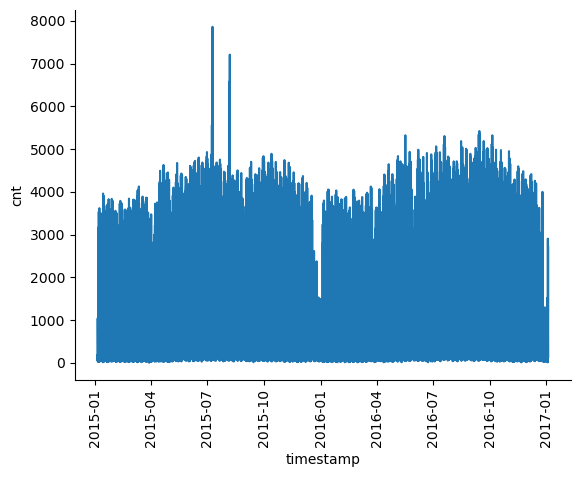

In [20]:
sns.lineplot(data=df, x=df.timestamp, y=df.cnt)
plt.xticks(rotation=90)
sns.despine()

Очень сложно что-то понять, нужно преобразовать данные, чтобы увидеть тренды

3.	Преобразуйте данные и посчитайте число поездок по дням. Визуализируйте результат.

In [21]:
df.sort_values('timestamp', inplace=True)
df.set_index('timestamp', drop=False, inplace=True)

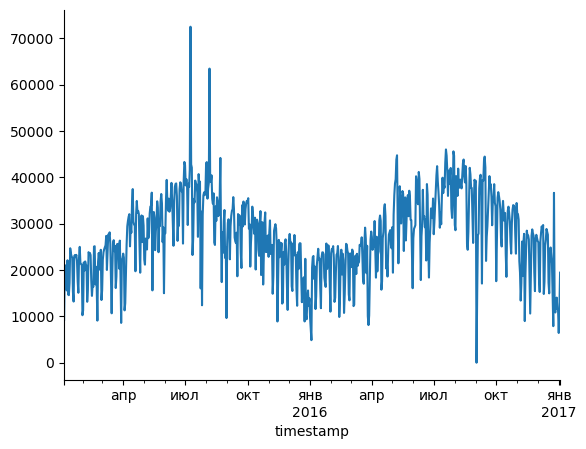

In [22]:
df.resample('D').cnt.sum().plot()
sns.despine()

Наблюдается сезонность, зимой аренды меньше, также есть очень резки скачки в положительную и отрицательную сторону

4.	Используйте агрегированные данные по дням и посчитайте скользящее среднее с окном 3. В качестве ответа укажите полученное число аренд за 2015-07-09, округлив значение до целого.

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 17414 entries, 2015-01-04 00:00:00 to 2017-01-03 23:00:00
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   timestamp     17414 non-null  datetime64[ns]
 1   cnt           17414 non-null  int64         
 2   t1            17414 non-null  float64       
 3   t2            17414 non-null  float64       
 4   hum           17414 non-null  float64       
 5   wind_speed    17414 non-null  float64       
 6   weather_code  17414 non-null  float64       
 7   is_holiday    17414 non-null  float64       
 8   is_weekend    17414 non-null  float64       
 9   season        17414 non-null  float64       
dtypes: datetime64[ns](1), float64(8), int64(1)
memory usage: 1.5 MB


In [28]:
by_day_roll = df.resample('D').cnt.sum().rolling(window=3).mean().reset_index().round(2)
by_day_roll.head()

,timestamp,cnt
0,2015-01-04,NaN
1,2015-01-05,NaN
2,2015-01-06,16739.67
3,2015-01-07,20683.00
4,2015-01-08,19092.67


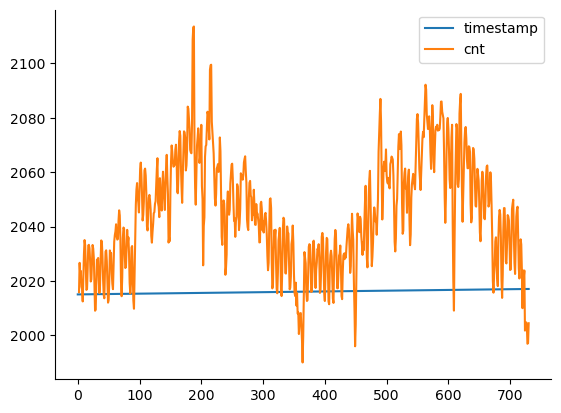

In [34]:
by_day_roll.plot()
sns.despine()

In [33]:
by_day_roll.query("timestamp == '2015-07-09'")


C:\Users\majkl\AppData\Local\Temp\ipykernel_6992\1710432558.py:1: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  by_day_roll.query("timestamp == '2015-07-09'")


,timestamp,cnt
186,2015-07-09,50705.0


Число аренд за 2015-07-09 равно 50705

5.	Посчитайте разницу между наблюдаемыми и значениями, подсчитанными с помощью скользящего среднего. Далее – найдите стандартное отклонение.

In [35]:
#наблюдаемые значения
by_day = df.resample('D').cnt.sum().reset_index()
by_day.head(3)

,timestamp,cnt
0,2015-01-04,9234
1,2015-01-05,20372
2,2015-01-06,20613


In [36]:
print(f'Разницу между наблюдаемыми и значениями равна {round(np.std(by_day['cnt'] - by_day_roll['cnt']), 2)}')

Разницу между наблюдаемыми и значениями равна 4558.59


In [ ]:
std = np.std(by_day['cnt'] - by_day_roll['cnt'])

In [41]:
print(f'Стандартное отклонение равно {std}')

Стандартное отклонение равно 4558.586633328807


6. Теперь определим границы интервалов. Для этого нужно взять данные, полученные при расчете скользящего среднего, и создать следующие объекты:

* upper_bound – верхняя граница; к скользящим средним прибавляем 2.576∗std
* lower_bound – нижняя граница; вычитаем 2.576∗std

Полученные значения запишите в новые столбцы датафрейма с агрегированными данными.

In [42]:
upper_bound = by_day_roll.cnt + (2.576 * std)
lower_bound = by_day_roll.cnt - (2.576 * std)

In [43]:
round(upper_bound.loc[730], 2)

24302.92

In [44]:
by_day['upper_bound'] = upper_bound
by_day['lower_bound'] = lower_bound
by_day.head()

,timestamp,cnt,upper_bound,lower_bound
0,2015-01-04,9234,NaN,NaN
1,2015-01-05,20372,NaN,NaN
2,2015-01-06,20613,28482.589167,4996.750833
3,2015-01-07,21064,32425.919167,8940.080833
4,2015-01-08,15601,30835.589167,7349.750833


7.	Изучите аномально высокие значения и укажите день, когда число аренд было наибольшим. Найдите причину данной аномалии.

In [45]:
by_day[by_day.cnt > by_day.upper_bound]

,timestamp,cnt,upper_bound,lower_bound
186,2015-07-09,72504,62447.919167,38962.080833
214,2015-08-06,63468,58370.249167,34884.410833
609,2016-09-04,27512,26001.919167,2516.080833
721,2016-12-25,36653,31393.589167,7907.750833


Аномальное число аренд было 2015-07-09 и составило 38962, скорее всего данная активность свзяана с забастовкой работников метро

8.	Изучите аномально низкие значения, найдите день с наименьшим числом аренд. Найдите причину данной аномалии.

In [47]:
by_day[by_day.cnt < by_day.lower_bound]

,timestamp,cnt,upper_bound,lower_bound
130,2015-05-14,15609,40452.249167,16966.410833
189,2015-07-12,23240,47779.589167,24293.750833
201,2015-07-24,16034,42756.589167,19270.750833
232,2015-08-24,17400,41272.249167,17786.410833
314,2015-11-14,8898,32780.249167,9294.410833
607,2016-09-02,0,37829.249167,14343.410833
615,2016-09-10,17080,43004.919167,19519.080833
621,2016-09-16,21967,47936.249167,24450.410833
678,2016-11-12,8990,32620.919167,9135.080833


Причина аномалии - это ошибка при сборе данных